In [1]:
import torch
import torch.nn
from torch.optim import Adam
from torch.utils.data import DataLoader
import vae_model
import train_vae
import DataPipeline
from pathlib import Path
import matplotlib.pyplot as plt
from pytorch3d.loss import chamfer_distance
import numpy as np
np.bool8 = np.bool
from torch.utils.tensorboard.writer import SummaryWriter
import datetime

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dataset = DataPipeline.PointCloudDataset(number_points=256)
point_cloud = dataset
print(f"Number of training examples: {len(point_cloud)}")
dataloader = DataLoader(dataset, shuffle=False, batch_size=1)
epochs = 5000

vae = vae_model.PointnetVAE(number_points=256, in_channels=3, hidden_channels=64, latent_dim=32)

num_parameters = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print(f"Trainable Parameters: {num_parameters / 1e6:.2f}M")



optimizer = torch.optim.Adam(vae.parameters(), lr=2e-4)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=T_max // 4, gamma=0.5)
scheduler = None
log_path = Path(f"logs/training/{datetime.datetime.now().strftime('%b%d_%H_%M')}_vae.pt")
writer = SummaryWriter(log_path)

Number of training examples: 50
Trainable Parameters: 0.28M


In [6]:
print(len(dataset))


50


In [18]:
vae_loss_history = []
kld_loss_history = []
reconstruction_loss_history = []

for epoch in range(epochs):
    best_loss = 1e6
    epoch_loss, reconstruction_loss, kld_loss = train_vae.train_one_epoch(vae, dataloader, optimizer, epochs, epoch, writer)

    vae_loss_history.append(epoch_loss)
    reconstruction_loss_history.append(reconstruction_loss)
    kld_loss_history.append(kld_loss)

    if scheduler is not None:
        scheduler.step()

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(vae.state_dict(), Path.cwd() / Path("vae2.pt"))

    if epoch % 500 == 0:
        print(f"Current Epoch Training Loss: {epoch_loss:.6f}")

fig = plt.figure()

plt.title("Losses over Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(vae_loss_history, color="m", label="VAE Loss")
plt.plot(reconstruction_loss_history, color="r", label="Chamfer Loss")
plt.plot(kld_loss_history, color="b", label="KLD Loss")
plt.legend()
plt.plot()
plt.show()

Current Epoch Training Loss: 0.059499
Current Epoch Training Loss: 0.014738
Current Epoch Training Loss: 0.005325
Current Epoch Training Loss: 0.003892
Current Epoch Training Loss: 0.003645
Current Epoch Training Loss: 0.003755
Current Epoch Training Loss: 0.003892
Current Epoch Training Loss: 0.004150
Current Epoch Training Loss: 0.005593
Current Epoch Training Loss: 0.004178


In [19]:
loader = DataLoader(point_cloud, batch_size=10, drop_last=True)
batch = next(iter(loader))
print(batch.shape)

torch.Size([10, 256, 3])


In [ ]:
vae_weights = torch.load()

In [ ]:
vae.load_state_dict(torch.load(Path.cwd() / Path("vae2.pt")))

<All keys matched successfully>

In [20]:
memorized_pc, _, _ = vae(batch)
print(memorized_pc.shape)
print(point_cloud[0].shape)
memorized_pc = memorized_pc.detach().cpu().numpy()

torch.Size([10, 256, 3])
torch.Size([256, 3])


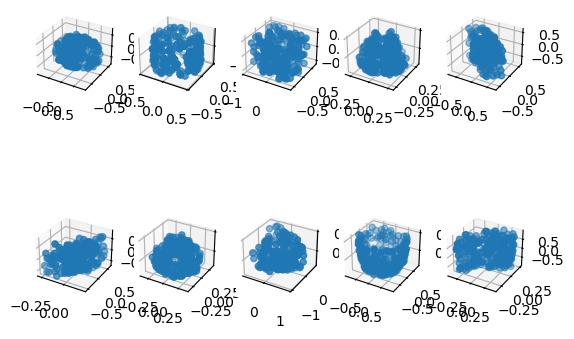

ValueError: num must be an integer with 1 <= num <= 10, not 11

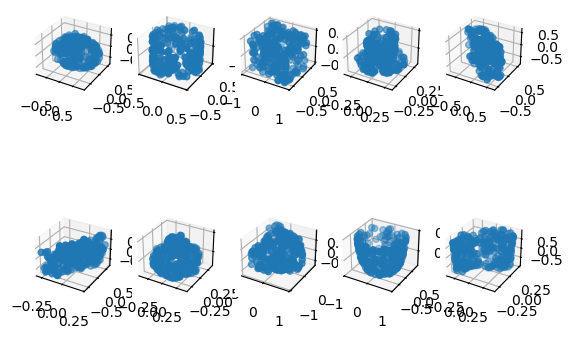

In [10]:
fig = plt.figure()
for i, pc in enumerate(memorized_pc[:10]):
    ax = fig.add_subplot(2, 5, i+1, projection="3d")
    ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2])
plt.show()

fig = plt.figure()
for i, pc in enumerate(point_cloud):
    pc = pc.detach().cpu().numpy()
    ax = fig.add_subplot(2, 5, i+1, projection="3d")
    ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2])
plt.show()

In [13]:
print(memorized_pc[:10].shape)
print(point_cloud.shape)

(10, 256, 3)


AttributeError: 'PointCloudDataset' object has no attribute 'shape'

In [22]:
%matplotlib qt
fig = plt.figure()
for i, pc in enumerate(memorized_pc[:10]):
    ax = fig.add_subplot(2, 5, i+1, projection="3d")
    ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2], color="b")
plt.show()

fig = plt.figure()
for i, pc in enumerate(point_cloud):
    pc = pc.detach().cpu().numpy()
    ax = fig.add_subplot(2, 5, i+1, projection="3d")
    ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2], color="r")
    if i >= 9:
        break
plt.show()

In [23]:
chamfer_loss = 0
for pred_pc, target_pc in zip(memorized_pc, point_cloud):
    chamfer_loss = chamfer_distance(torch.tensor(pred_pc).unsqueeze(0), torch.tensor(target_pc).unsqueeze(0))[0]
    print(chamfer_loss)


tensor(0.0019)
tensor(0.0016)
tensor(0.0015)
tensor(0.0007)
tensor(0.0013)
tensor(0.0014)
tensor(0.0006)
tensor(0.0021)
tensor(0.0010)
tensor(0.0011)


C:\Users\chris\AppData\Local\Temp\ipykernel_11360\1459045490.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  chamfer_loss = chamfer_distance(torch.tensor(pred_pc).unsqueeze(0), torch.tensor(target_pc).unsqueeze(0))[0]
